# Logit Lens

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iliad-team/iliad-intensive-C.2/blob/main/exercises/01_logit_lens/notebook_normal.ipynb)

In [1]:
import os, importlib

if os.getenv('COLAB_RELEASE_TAG'):
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/iliad-team/iliad-intensive-C.2/main/exercises/01_logit_lens/utils.py",
        "utils.py"
    )
    %pip install transformer_lens einops matplotlib "numpy==2.0.2" "transformers>=4.38,<4.52" -q

import utils
importlib.reload(utils)
from utils import test_get_residual_streams, test_logit_lens, test_top_k_tokens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 68.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plum-dispatch 2.9.0 requires beartype>=0.16.2; p

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Loading GPT-2 Small

We use TransformerLens to load GPT-2 Small (80M parameters, 12 layers).
`HookedTransformer` wraps the model and gives us access to all intermediate activations.

In [3]:
model = HookedTransformer.from_pretrained("gpt2-small")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


## The Residual Stream and `run_with_cache`

A transformer builds up its prediction layer by layer through the **residual stream**.
Each layer reads from and writes to this stream.

The key tool for inspecting internals is `model.run_with_cache(tokens)`.
It runs the forward pass and returns both the final logits and a `cache` object containing every intermediate activation.

Run the cell below and inspect the output — look at the cache keys and shapes to understand what's available.

In [4]:
text = "The quick brown fox jumps over the lazy"
tokens = model.to_tokens(text)
logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)

print(f"Tokens shape: {tokens.shape}")
print(f"Logits shape: {logits.shape}")
print(f"\nCache contains {len(cache)} activations. Some examples:")
for key in ["blocks.0.hook_resid_post", "blocks.5.hook_resid_post", "blocks.11.hook_resid_post"]:
    print(f"  cache['{key}'].shape = {cache[key].shape}")

Tokens shape: torch.Size([1, 9])
Logits shape: torch.Size([1, 9, 50257])

Cache contains 208 activations. Some examples:
  cache['blocks.0.hook_resid_post'].shape = torch.Size([9, 768])
  cache['blocks.5.hook_resid_post'].shape = torch.Size([9, 768])
  cache['blocks.11.hook_resid_post'].shape = torch.Size([9, 768])


The residual stream after layer $i$ is stored at `blocks.{i}.hook_resid_post` with shape `(seq_len, d_model)`.

We can also unembed any residual stream vector back to vocabulary logits using `model.unembed`.
Let's verify we understand the shapes:

In [5]:
resid_layer_11 = cache["blocks.11.hook_resid_post"]
print(f"Residual stream at layer 11: {resid_layer_11.shape}")
print(f"Unembedding weight shape:    {model.unembed.W_U.shape}")
print(f"Vocabulary size:             {model.cfg.d_vocab}")
print(f"Number of layers:            {model.cfg.n_layers}")

Residual stream at layer 11: torch.Size([9, 768])
Unembedding weight shape:    torch.Size([768, 50257])
Vocabulary size:             50257
Number of layers:            12


## Exercise A: Extract Residual Streams

The first step of logit lens is collecting the residual stream at every layer.

Write a function that takes a model and tokens, runs the model with caching, and returns the residual stream at each layer stacked into a single tensor of shape `(seq_len, n_layers, d_model)`.


In [10]:
def get_residual_streams(model, tokens):
    """
    Args:
        model: HookedTransformer
        tokens: (1, seq_len) token IDs
    Returns:
        (seq_len, n_layers, d_model) tensor of residual stream activations
    """
    # Step 1: run the model with caching (remove batch dim)
    _, cache = model.run_with_cache(tokens, remove_batch_dim=True)
    # TODO (~1 line)

    # Step 2: collect residual stream at each layer into a list
    # TODO (~1 line): use cache[f"blocks.{i}.hook_resid_post"] for each layer
    streams = [cache[f"blocks.{i}.hook_resid_post"] for i in range(model.cfg.n_layers)]

    # Step 3: stack into (seq_len, n_layers, d_model)
    # TODO (~1 line): torch.stack with the right dim
    # streams_arr = torch.stack(streams).permute(1,0,2)
    return torch.stack(streams, dim=1)

In [11]:
test_get_residual_streams(get_residual_streams, model)

Testing get_residual_streams... PASS


<details>
<summary><b>Hint</b></summary>

Use `model.run_with_cache(tokens, remove_batch_dim=True)` to get the cache.
Then loop over `range(model.cfg.n_layers)` and collect `cache[f"blocks.{i}.hook_resid_post"]`.
Use `torch.stack(..., dim=1)` to combine them along the layer dimension.
</details>

<details>
<summary><b>Solution</b></summary>

```python
def get_residual_streams(model, tokens):
    _, cache = model.run_with_cache(tokens, remove_batch_dim=True)
    streams = [cache[f"blocks.{i}.hook_resid_post"] for i in range(model.cfg.n_layers)]
    return torch.stack(streams, dim=1)
```
</details>

## Exercise B: Logit Lens

Now for the core of logit lens: at each layer, unembed the residual stream to get a distribution over the vocabulary, then compare it to the model's final prediction.

For each layer $i$ and position $t$:
1. **Unembed** the residual stream to get logits
2. **Get the top prediction**: the token with the highest logit
3. **Measure divergence**: compute the KL divergence from the final layer's distribution to this layer's distribution

$$D_{\text{KL}}(P_{\text{final}} \| P_{\text{layer}}) = \sum_v P_{\text{final}}(v) \log \frac{P_{\text{final}}(v)}{P_{\text{layer}}(v)}$$

`torch.nn.functional.kl_div` expects **log-probabilities** as the first argument and **probabilities** as the second:
```
kl_div(input=log_probs, target=probs, reduction="none")
```

In [21]:
def logit_lens(model, tokens):
    """
    Args:
        model: HookedTransformer
        tokens: (1, seq_len) token IDs
    Returns:
        top_tokens: (seq_len, n_layers) most likely token ID at each position and layer
        kl_divs: (seq_len, n_layers) KL divergence from final layer prediction
    """
    # Step 1: get residual streams (seq_len, n_layers, d_model)
    residual_streams = get_residual_streams(model, tokens)

    # Step 2: unembed to get logits (seq_len, n_layers, vocab_size)
    # TODO (~1 line): apply model.unembed to residual_streams
    layer_logits = model.unembed(residual_streams)

    # Step 3: get top token predictions (seq_len, n_layers)
    # TODO (~1 line): argmax over vocabulary dimension
    top_tokens = torch.argmax(layer_logits, dim = 2)

    # Step 4: compute log-probs for each layer and probs for the final layer
    # TODO (~2 lines): log_softmax for all layers, softmax for final layer only (expand to match)
    layer_log_probs = torch.log_softmax(layer_logits, dim = 2)
    final_probs = layer_logits[:, -1:, :].softmax(dim=-1).expand_as(layer_log_probs)

    # Step 5: KL divergence from final layer to each layer
    # TODO (~1 line): use torch.nn.functional.kl_div, sum over vocab dim
    kl_divs = torch.nn.functional.kl_div(input = layer_log_probs, target = final_probs, reduction = 'none').sum(dim=2)

    return top_tokens, kl_divs

In [22]:
test_logit_lens(logit_lens, model)

Testing logit_lens... PASS


<details>
<summary><b>Hint 1: Unembedding</b></summary>

`model.unembed` can handle the `(seq_len, n_layers, d_model)` shape directly.
</details>

<details>
<summary><b>Hint 2: Final layer probs</b></summary>

Take softmax of the last layer's logits and expand to match all layers:
`layer_logits[:, -1:, :].softmax(dim=-1).expand_as(layer_log_probs)`
</details>

<details>
<summary><b>Solution</b></summary>

```python
def logit_lens(model, tokens):
    residual_streams = get_residual_streams(model, tokens)
    layer_logits = model.unembed(residual_streams)
    top_tokens = layer_logits.argmax(dim=-1)
    layer_log_probs = layer_logits.log_softmax(dim=-1)
    final_probs = layer_logits[:, -1:, :].softmax(dim=-1).expand_as(layer_log_probs)
    kl_divs = torch.nn.functional.kl_div(layer_log_probs, final_probs, reduction="none").sum(dim=-1)
    return top_tokens, kl_divs
```
</details>

## Visualizing Logit Lens

Let's visualize how GPT-2's predictions evolve across layers.
Red = high KL divergence (prediction differs from final); white = converged.

In [23]:
def plot_logit_lens(model, text):
    tokens = model.to_tokens(text)
    top_tokens, kl_divs = logit_lens(model, tokens)
    str_tokens = model.to_str_tokens(text)

    seq_len, n_layers = top_tokens.shape
    fig, ax = plt.subplots(figsize=(max(10, seq_len * 0.8), n_layers * 0.6))

    cmap = plt.cm.Reds
    norm = plt.Normalize(vmin=0, vmax=kl_divs.max().item())

    for i in range(seq_len):
        for j in range(n_layers):
            color = cmap(norm(kl_divs[i, j].item()))
            ax.add_patch(plt.Rectangle((i, j), 1, 1, facecolor=color, edgecolor="gray", lw=0.5))
            token_str = model.tokenizer.decode([top_tokens[i, j].item()])
            ax.text(i + 0.5, j + 0.5, token_str, ha="center", va="center", fontsize=7)

    ax.set_xlim(0, seq_len)
    ax.set_ylim(0, n_layers)
    ax.set_xticks(np.arange(seq_len) + 0.5)
    ax.set_xticklabels(str_tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(n_layers) + 0.5)
    ax.set_yticklabels([f"Layer {i}" for i in range(n_layers)], fontsize=8)
    ax.set_xlabel("Input token")
    ax.set_ylabel("Layer")
    ax.set_title("Logit Lens: top prediction at each layer (red = far from final)")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="KL divergence from final layer")
    plt.tight_layout()
    plt.show()

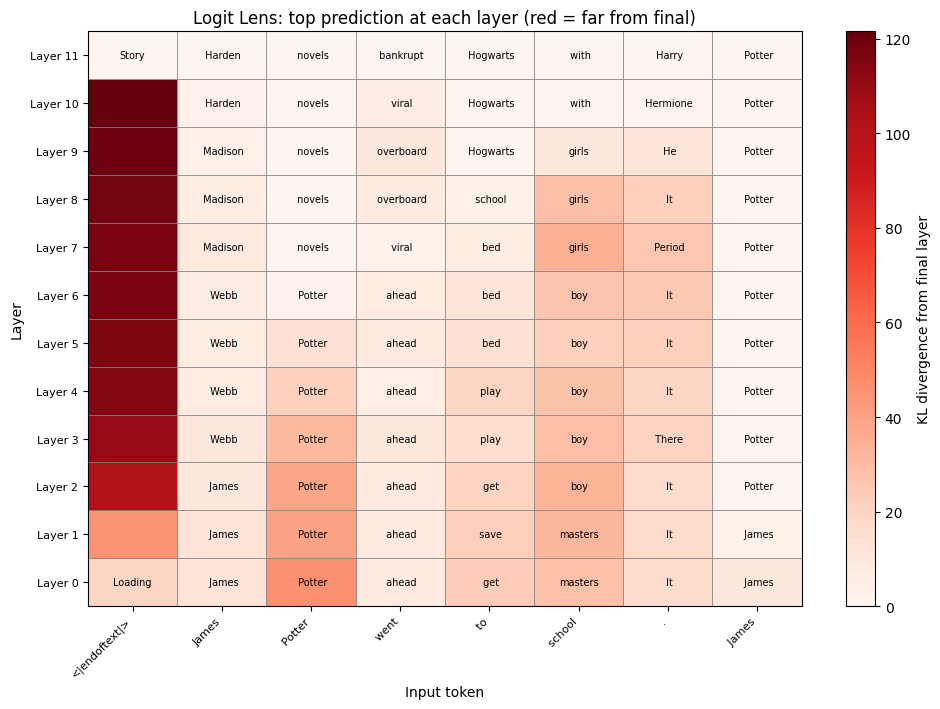

In [24]:
plot_logit_lens(model, "James Potter went to school. James")

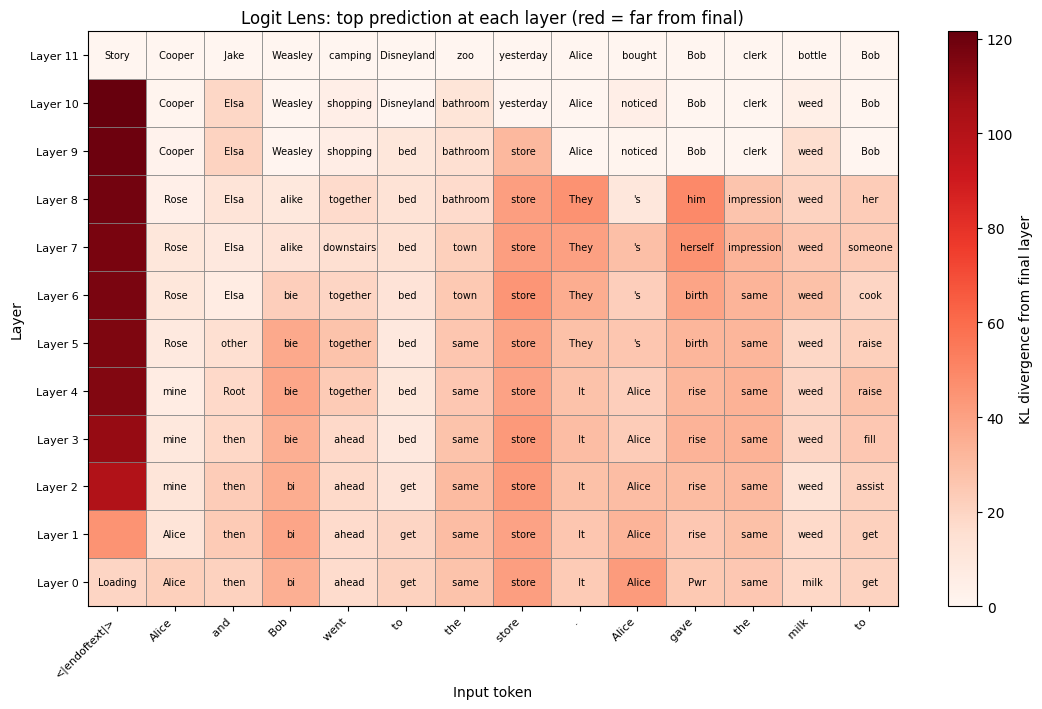

In [25]:
plot_logit_lens(model, "Alice and Bob went to the store. Alice gave the milk to")

<details>
<summary><b>What to look for</b></summary>

- At which layer does the model start predicting "Potter" after "James"?
- In the second example, when does "Bob" appear as the top prediction for the final position?
- Notice how early layers often predict generic/frequent tokens, while later layers refine to context-specific ones.

Try your own prompts!
</details>

## Exercise C: Decode Top-K Predictions

For deeper inspection, it's useful to see not just the top-1 prediction but the top-k tokens and their probabilities at any layer and position.

Write a function that takes a residual stream vector and returns the top-k most likely tokens with their probabilities.

In [ ]:
def top_k_tokens(model, residual_vec, k=10):
    """
    Args:
        model: HookedTransformer
        residual_vec: (d_model,) single residual stream vector
        k: number of top tokens to return
    Returns:
        list of (token_string, probability) tuples, sorted by descending probability
    """
    # Step 1: unembed the vector to get logits (need to add batch dims)
    # TODO (~1 line): model.unembed expects (batch, seq, d_model)
    logits = None

    # Step 2: convert to probabilities
    # TODO (~1 line)
    probs = None

    # Step 3: get top-k values and indices
    # TODO (~1 line)
    values, indices = None, None

    # Step 4: decode each index to a token string
    # TODO (~1 line): use model.tokenizer.decode([idx.item()])
    return None

In [ ]:
test_top_k_tokens(top_k_tokens, model)

<details>
<summary><b>Hint</b></summary>

1. `model.unembed(residual_vec[None, None, :]).squeeze()` gives vocabulary logits.
2. `.softmax(dim=-1)` gives probabilities.
3. `torch.topk(probs, k)` returns values and indices.
</details>

<details>
<summary><b>Solution</b></summary>

```python
def top_k_tokens(model, residual_vec, k=10):
    logits = model.unembed(residual_vec[None, None, :]).squeeze()
    probs = logits.softmax(dim=-1)
    values, indices = probs.topk(k)
    return [(model.tokenizer.decode([idx.item()]), val.item()) for val, idx in zip(values, indices)]
```
</details>

## Exploration: Probe Individual Layers

Use `top_k_tokens` to inspect what GPT-2 "thinks" at different layers for a given position.
This gives much richer information than just the top-1 token.

In [ ]:
text = "The Eiffel Tower is located in"
tokens = model.to_tokens(text)
residual_streams = get_residual_streams(model, tokens)
str_tokens = model.to_str_tokens(text)

last_pos = -1
print(f"Predicting next token after: {''.join(str_tokens[:last_pos])}[{str_tokens[last_pos]}]")
print()
for layer in [0, 3, 6, 9, 11]:
    preds = top_k_tokens(model, residual_streams[last_pos, layer], k=5)
    top_str = ", ".join(f"{tok!r}: {p:.3f}" for tok, p in preds)
    print(f"Layer {layer:2d}: {top_str}")